# GlobalMart Superstore Analysis

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('SUPER1.csv', encoding='latin1')

# Display first rows
df.head()


C:\Users\dasra\AppData\Local\Temp\ipykernel_2792\3530296767.py:6: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('SUPER1.csv', encoding='latin1')


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Regional Manager,Product ID,Category,Sub-Category,Product Name,Returned,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,08-11-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Cassandra Brandow,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,No,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,08-11-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Cassandra Brandow,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",No,731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12-06-2016,16-06-2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Anna Andreadi,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,No,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11-10-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Cassandra Brandow,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,No,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11-10-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Cassandra Brandow,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,No,22.3680,2,0.20,2.5164


In [2]:

# 1. Average Sales by Category, Sub-Category and Segment

pivot_table = pd.pivot_table(
    df,
    values='Sales',
    index=['Category', 'Sub-Category'],
    columns='Segment',
    aggfunc='mean'
).round(2)

print(pivot_table)


Segment                       Consumer  Corporate  Home Office
Category        Sub-Category                                  
Furniture       Bookcases       601.50     598.34       545.97
                Chairs          462.83     459.19       466.02
                Furnishings     113.91     105.67       114.63
                Tables          772.66     781.87       787.59
Office Supplies Appliances      442.05     449.84       508.52
                Art              66.44      65.65        63.50
                Binders         102.52      82.96        91.26
                Envelopes        68.42      70.85        68.86
                Fasteners        30.84      39.19        29.73
                Labels           29.92      30.68        26.73
                Paper            61.29      63.45        71.33
                Storage         219.98     245.94       249.61
                Supplies        127.83     131.97        78.36
Technology      Accessories     231.63     236.22      

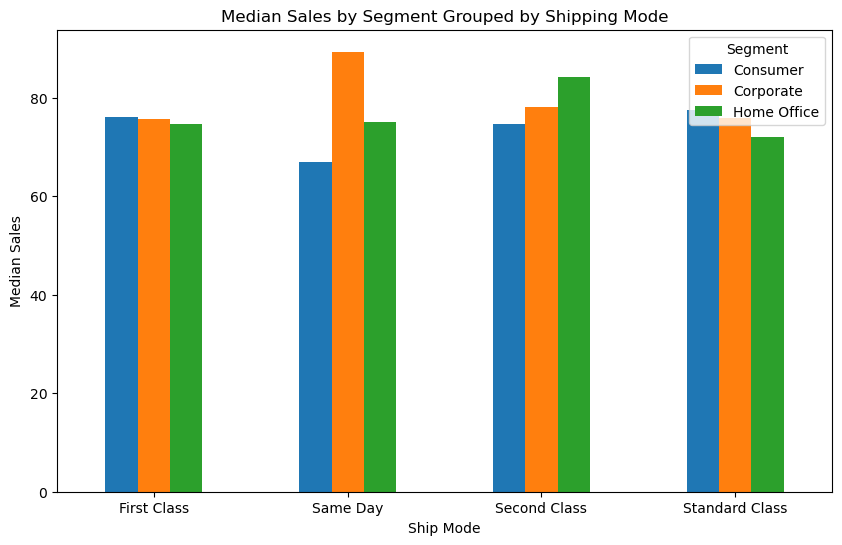

In [3]:

# 2. Median Sales by Segment grouped by Ship Mode

median_sales = df.groupby(['Ship Mode', 'Segment'])['Sales'].median().unstack()

median_sales.plot(kind='bar', figsize=(10,6))
plt.title('Median Sales by Segment Grouped by Shipping Mode')
plt.ylabel('Median Sales')
plt.xlabel('Ship Mode')
plt.xticks(rotation=0)
plt.show()


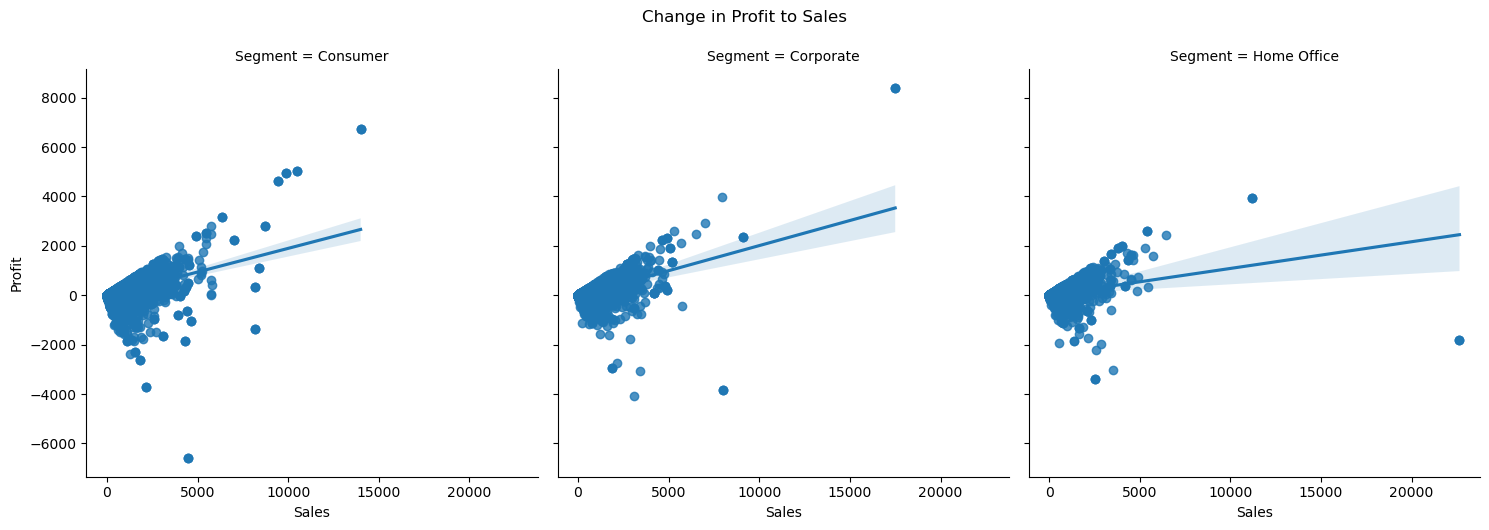

In [4]:

# 3. Change in Profit to Sales

g = sns.lmplot(
    data=df,
    x='Sales',
    y='Profit',
    col='Segment',
    height=5,
    aspect=1
)

g.fig.suptitle('Change in Profit to Sales', y=1.05)
plt.show()


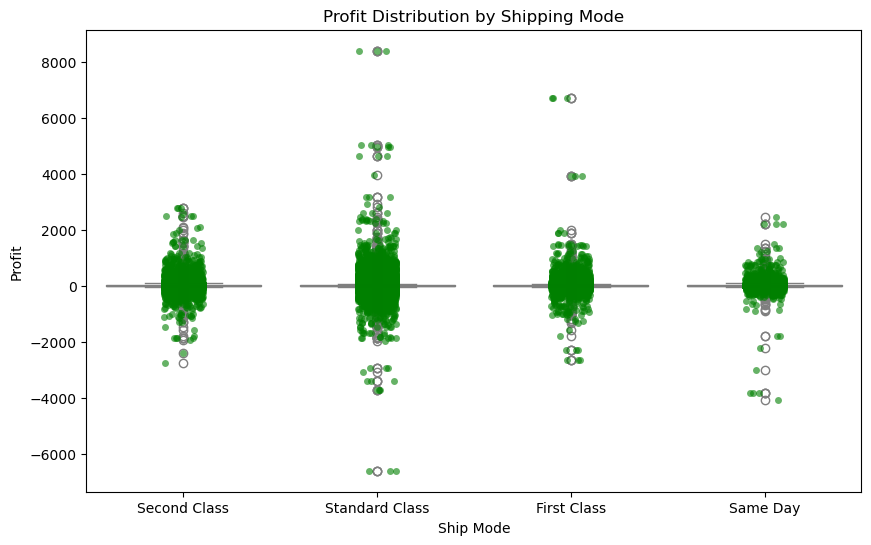

In [5]:

# 4. Profit Distribution by Shipping Mode

plt.figure(figsize=(10,6))

sns.boxplot(x='Ship Mode', y='Profit', data=df, color='lightgray')
sns.stripplot(x='Ship Mode', y='Profit', data=df, color='green', alpha=0.6)

plt.title('Profit Distribution by Shipping Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Profit')

plt.show()
